In [ ]:
#Magda Michalska
#Dominika Romanowska
#Julia Zawadzka

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
#wczytywanie danych
gdzie_jestem = os.getcwd()
print(gdzie_jestem)
plik = os.path.join(gdzie_jestem, 'python_dane.xlsx')
print(plik)
dane = pd.read_excel(plik, sheet_name = 'Arkusz1', header = 0)
dane.set_index(['Country'], inplace = True)
dane.head()

C:\Users\J\Desktop\studia\analiza_danych_python
C:\Users\J\Desktop\studia\analiza_danych_python\python_dane.xlsx


,Unemployment,Average usual weekly hours worked,Female employment rate,Male employment rate,Youth employment rate,Gender pay gap
Country,,,,,,
Belgium,5.7,36.2,63.3,70.2,26.3,0.7
Bulgaria,4.2,40.0,67.6,74.1,17.3,12.0
Czechia,2.6,39.4,69.5,81.1,24.5,18.5
Denmark,6.2,33.5,74.5,79.9,59.0,14.0
Germany,3.4,34.8,74.1,80.7,51.2,15.6


In [3]:
#statystyki opisowe
print(dane.describe())

       Unemployment  Average usual weekly hours worked  \
count     27.000000                          27.000000   
mean       5.811111                          37.937037   
std        2.168717                           2.267012   
min        2.600000                          31.600000   
25%        4.250000                          36.650000   
50%        5.400000                          38.800000   
75%        7.000000                          39.550000   
max       11.400000                          41.000000   

       Female employment rate  Male employment rate  Youth employment rate  \
count               27.000000             27.000000              27.000000   
mean                68.485185             75.974074              34.503704   
std                  6.316140              4.348615              14.129823   
min                 53.300000             70.200000              17.300000   
25%                 66.800000             72.050000              25.300000   
50%      

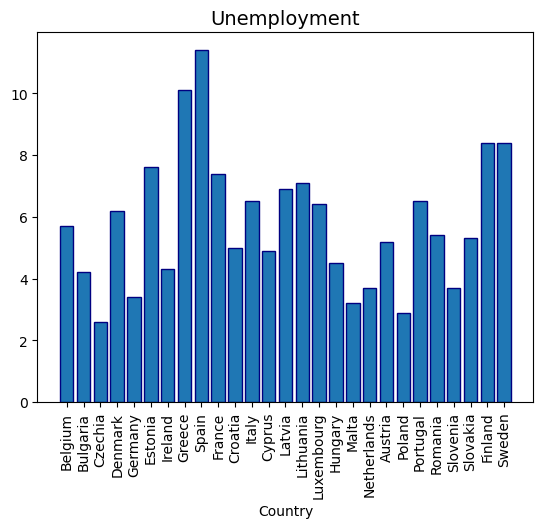

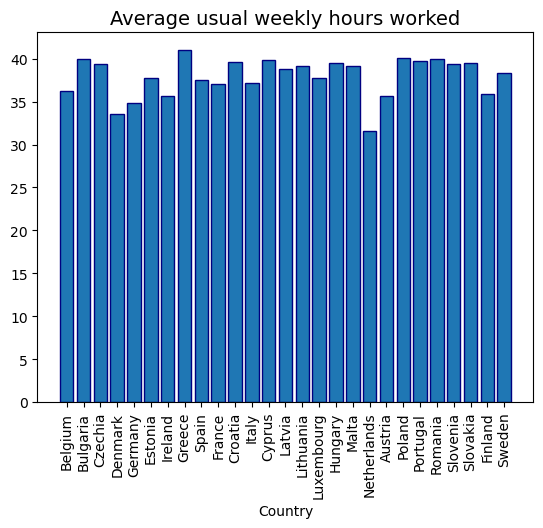

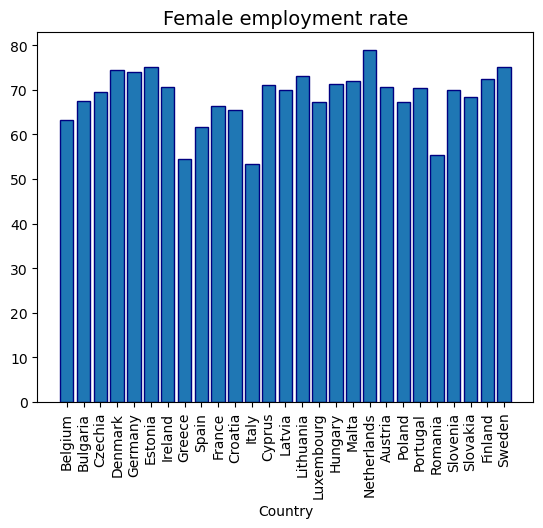

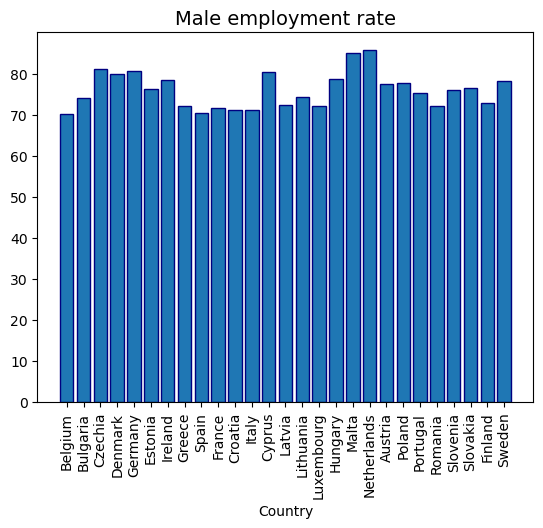

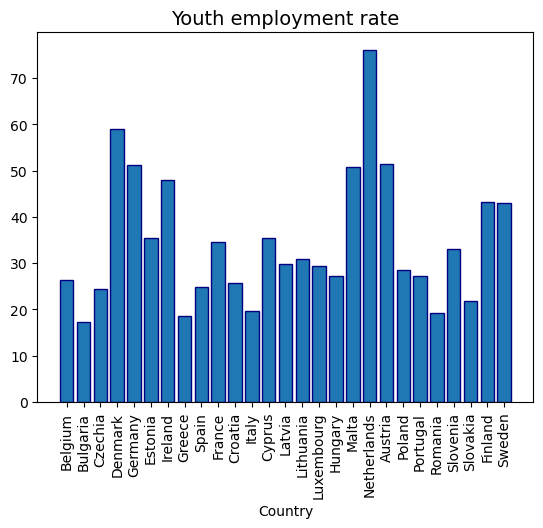

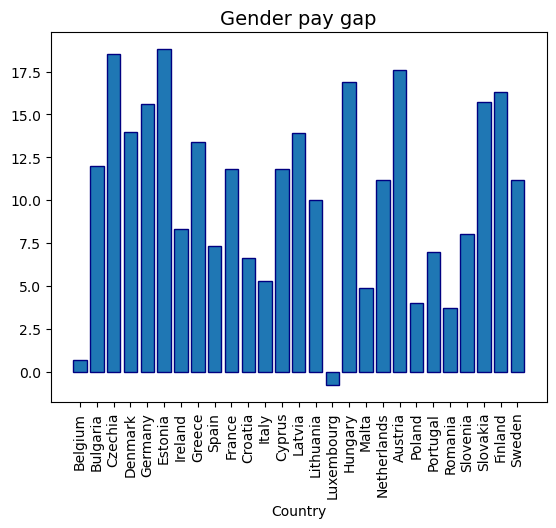

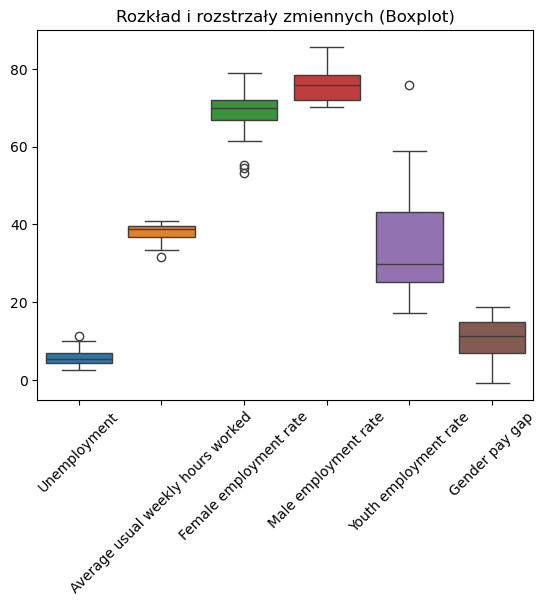

In [4]:
cols = dane.columns
for col in cols:
    plt.figure()
    
    plt.bar(dane.index, dane[col], edgecolor='navy')
    
    plt.title(f'{col}', fontsize=14)
    plt.xlabel('Country')
    
    plt.xticks(rotation=90)
    plt.show()
   
plt.figure()
sb.boxplot(data=dane)
plt.title("Rozkład i rozstrzały zmiennych (Boxplot)")
plt.xticks(rotation=45)
plt.show()

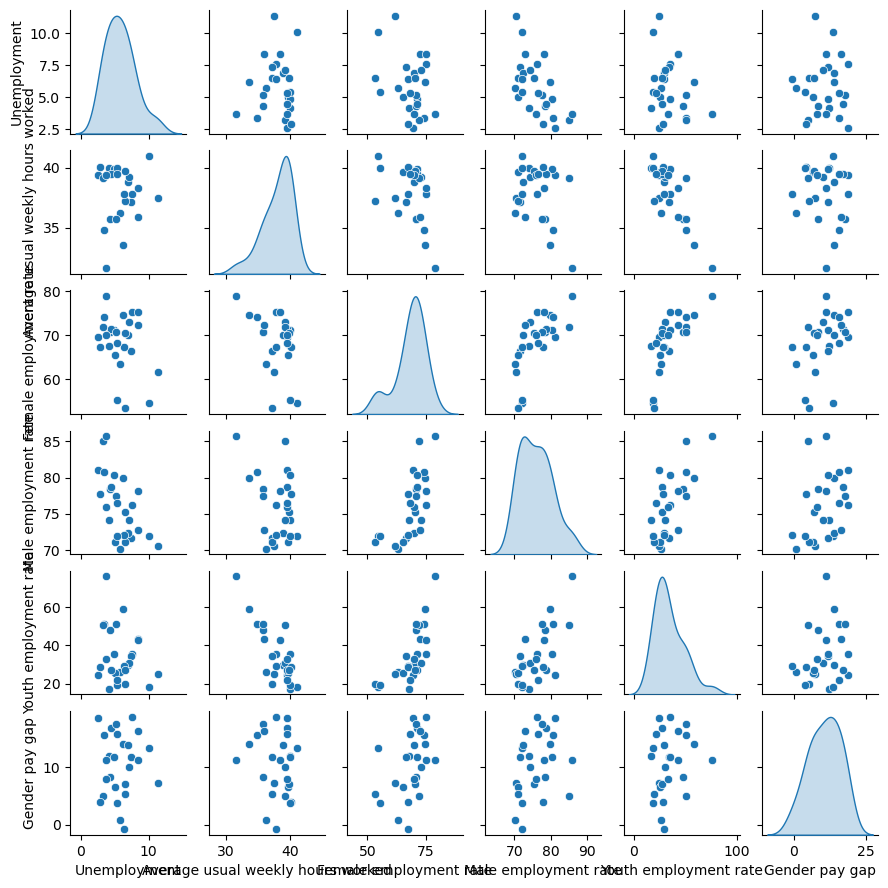

<Axes: >

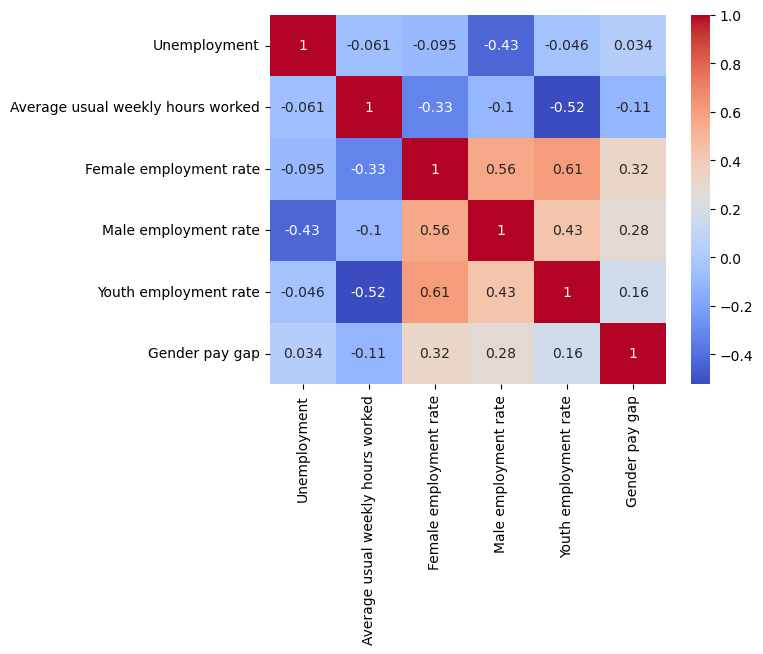

In [5]:
sb.pairplot(dane, kind = 'scatter', diag_kind = 'kde', height = 1.5)
plt.show()

#korelacja
sb.heatmap(dane.corr('kendall'), cmap = 'coolwarm', annot = True)

In [6]:
#######################################################################
#skalowanie danych

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
dane_skalowane = scaler.fit_transform(dane)
dane_skalowane_df = pd.DataFrame(dane_skalowane, index=dane.index, columns=dane.columns)

# Statystyki po przeskalowaniu
print(dane_skalowane_df.describe())

       Unemployment  Average usual weekly hours worked  \
count  2.700000e+01                       2.700000e+01   
mean  -6.908054e-16                       2.014849e-16   
std    1.019049e+00                       1.019049e+00   
min   -1.508856e+00                      -2.848574e+00   
25%   -7.335440e-01                      -5.785387e-01   
50%   -1.931753e-01                       3.879122e-01   
75%    5.586420e-01                       7.250463e-01   
max    2.626140e+00                       1.376839e+00   

       Female employment rate  Male employment rate  Youth employment rate  \
count            2.700000e+01          2.700000e+01           2.700000e+01   
mean            -2.220446e-16         -2.072416e-15           2.837237e-16   
std              1.019049e+00          1.019049e+00           1.019049e+00   
min             -2.449986e+00         -1.353090e+00          -1.240739e+00   
25%             -2.718887e-01         -9.195628e-01          -6.637753e-01   
50%      

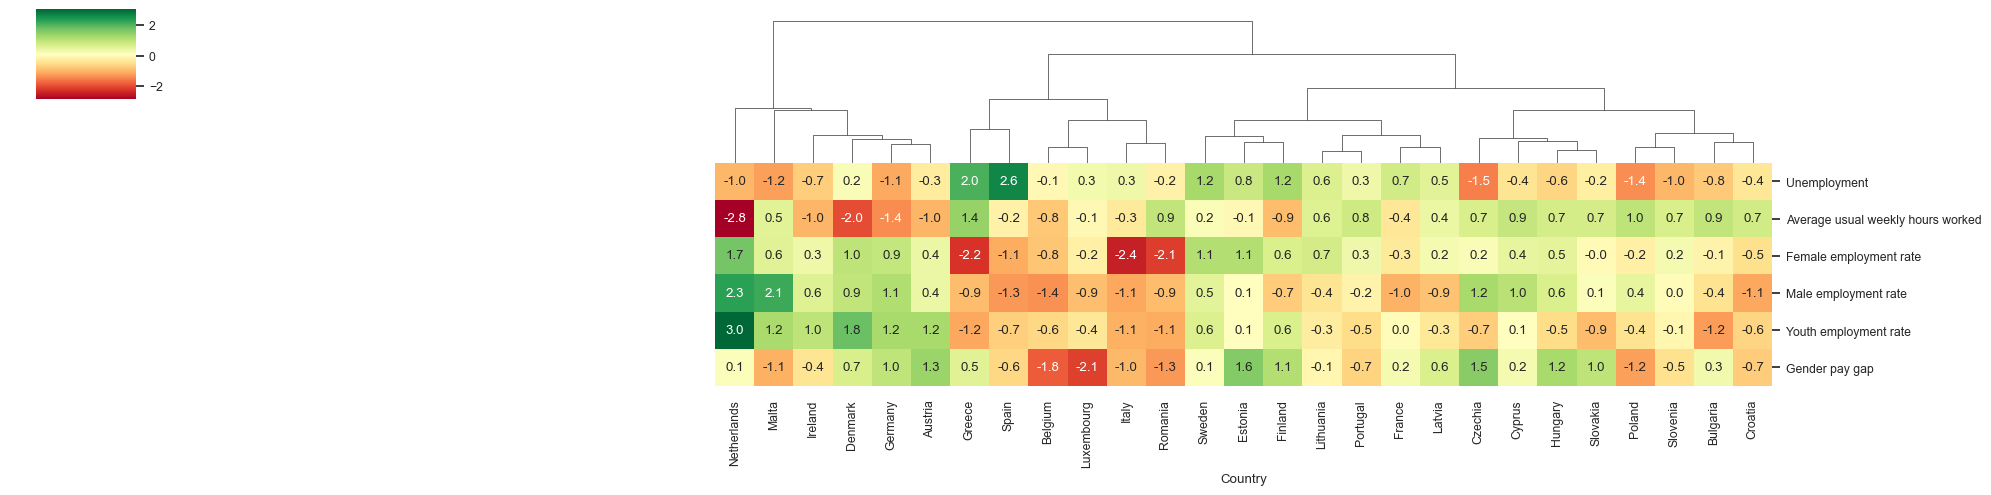

In [7]:
sb.set(font_scale=0.8)
g = sb.clustermap(dane_skalowane_df.T, 
                   cmap="RdYlGn",    
                   annot=dane_skalowane_df.values.T,
                   fmt=".1f",
                   method='ward',
                   metric='euclidean', 
                  row_cluster=False,
                  dendrogram_ratio=(0.4),
                   figsize=(20, 5))
plt.show()

In [8]:
from sklearn.decomposition import PCA
from scipy.spatial import ConvexHull
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.cm as cm

In [9]:
# 4 klastry dobrane na podstawie teorii

Średnie wartości w klastrach:
Cluster                                    1          2          3      4
Unemployment                        7.633333   4.200000   7.214286   4.56
Average usual weekly hours worked  37.850000  39.622222  38.471429  34.26
Female employment rate             72.033333  69.711111  60.100000  73.76
Male employment rate               74.200000  78.322222  71.285714  80.44
Youth employment rate              36.150000  29.522222  23.371429  57.08
Gender pay gap                     13.666667  10.977778   5.171429  13.34


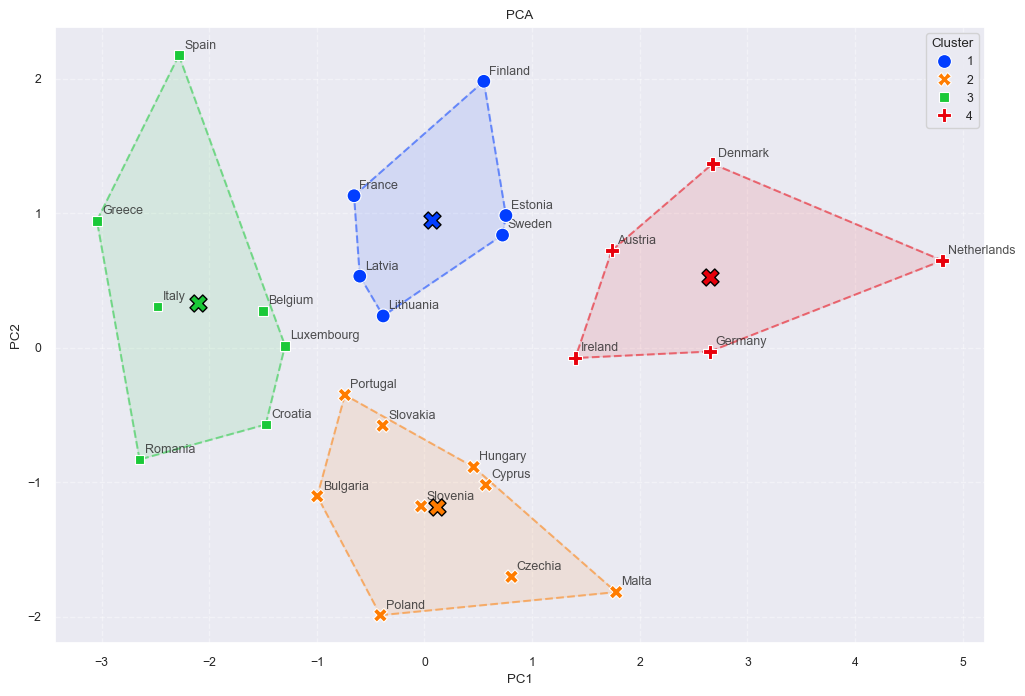

PC1: 52.25%
PC2: 19.67%

Suma: 71.93%
Wpływ poszczególnych zmiennych na składowe:
                                        PC1       PC2
Unemployment                      -0.265696  0.740737
Average usual weekly hours worked -0.374789 -0.491156
Female employment rate             0.482318  0.011547
Male employment rate               0.485050 -0.335581
Youth employment rate              0.512410  0.234587
Gender pay gap                     0.241808  0.205660


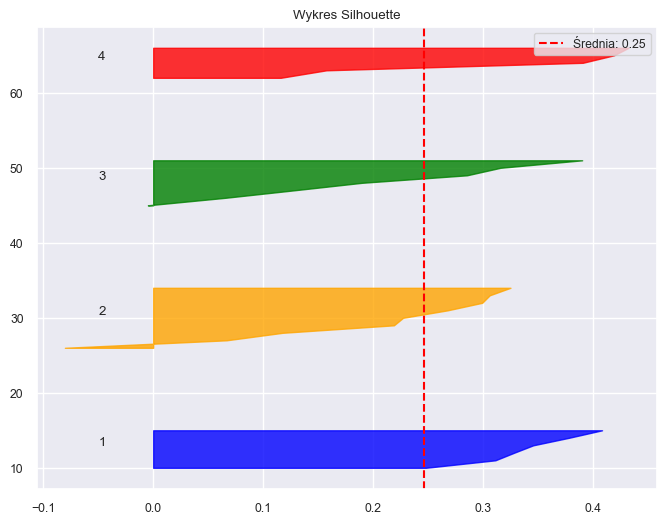

Średni Silhouette Score dla k=4 wynosi: 0.2465
1 0.3367
2 0.1943
3 0.1958
4 0.3032


In [10]:
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
import os
os.environ["OMP_NUM_THREADS"] = "1"
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")


k = 4

clustering = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
grupy = clustering.fit_predict(dane_skalowane_df)

df_results = dane.copy()
df_results['Cluster'] = grupy + 1 

cluster_summary = df_results.groupby('Cluster').mean()
print("Średnie wartości w klastrach:")
print(cluster_summary.T)

pca = PCA(n_components=2)
pca_results = pca.fit_transform(dane_skalowane_df)
df_pca = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'], index=dane.index)
df_pca['Cluster'] = df_results['Cluster']

plt.figure(figsize=(12, 8))
colors = sb.color_palette('bright', n_colors=k)
ax = sb.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', 
                    palette=colors, s=100, style='Cluster', zorder=5)

for i in range(1, k + 1):
    cluster_points = df_pca[df_pca['Cluster'] == i][['PC1', 'PC2']].values
    
    centroid = cluster_points.mean(axis=0)
    plt.scatter(centroid[0], centroid[1], marker='X', s= 150, 
                color=colors[i-1], edgecolors='black', label=f'Centroid {i}', zorder=10)
    
    if len(cluster_points) >= 3:
        hull = ConvexHull(cluster_points)
        for simplex in hull.simplices:
            plt.plot(cluster_points[simplex, 0], cluster_points[simplex, 1], 
                     color=colors[i-1], linestyle='--', alpha=0.5)
        plt.fill(cluster_points[hull.vertices, 0], cluster_points[hull.vertices, 1], 
                 color=colors[i-1], alpha=0.1)

for i in range(df_pca.shape[0]):
    plt.text(df_pca['PC1'].iloc[i] + 0.05, df_pca['PC2'].iloc[i] + 0.05, 
             df_pca.index[i], fontsize=9, alpha=0.8)

plt.title("PCA")
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()


plt.figure(figsize=(8, 6))
silhouette_avg = silhouette_score(dane_skalowane_df, grupy)
sample_silhouette_values = silhouette_samples(dane_skalowane_df, grupy)

variance_ratios = pca.explained_variance_ratio_

for i, ratio in enumerate(variance_ratios):
    print(f"PC{i+1}: {ratio:.2%}")

print(f"\nSuma: {sum(variance_ratios):.2%}")

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=dane.columns
)

print("Wpływ poszczególnych zmiennych na składowe:")
print(loadings)
custom_colors = ['blue', 'orange', 'green', 'red', 'violet']
y_lower = 10
for i in range(k):
    ith_cluster_values = sample_silhouette_values[grupy == i]
    ith_cluster_values.sort()

    size_cluster_i = ith_cluster_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = custom_colors[i] 
    
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_values,
                      facecolor=color, edgecolor=color, alpha=0.8)

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i + 1))
    y_lower = y_upper + 10

plt.axvline(x=silhouette_avg, color="red", linestyle="--", label=f'Średnia: {silhouette_avg:.2f}')
plt.title("Wykres Silhouette")
plt.legend(loc="upper right")
plt.show()

print(f"Średni Silhouette Score dla k={k} wynosi: {silhouette_avg:.4f}")

silhouette_per_cluster = {}

for i in range(1, k + 1):
        cluster_values = sample_silhouette_values[df_results['Cluster'] == i]
    
        avg_score = cluster_values.mean()
        silhouette_per_cluster[i] = avg_score
        linia = f"{i} {avg_score:.4f}"
        print(linia)    


cluster_summary.loc['Silhouette_Score'] = pd.Series(silhouette_per_cluster)

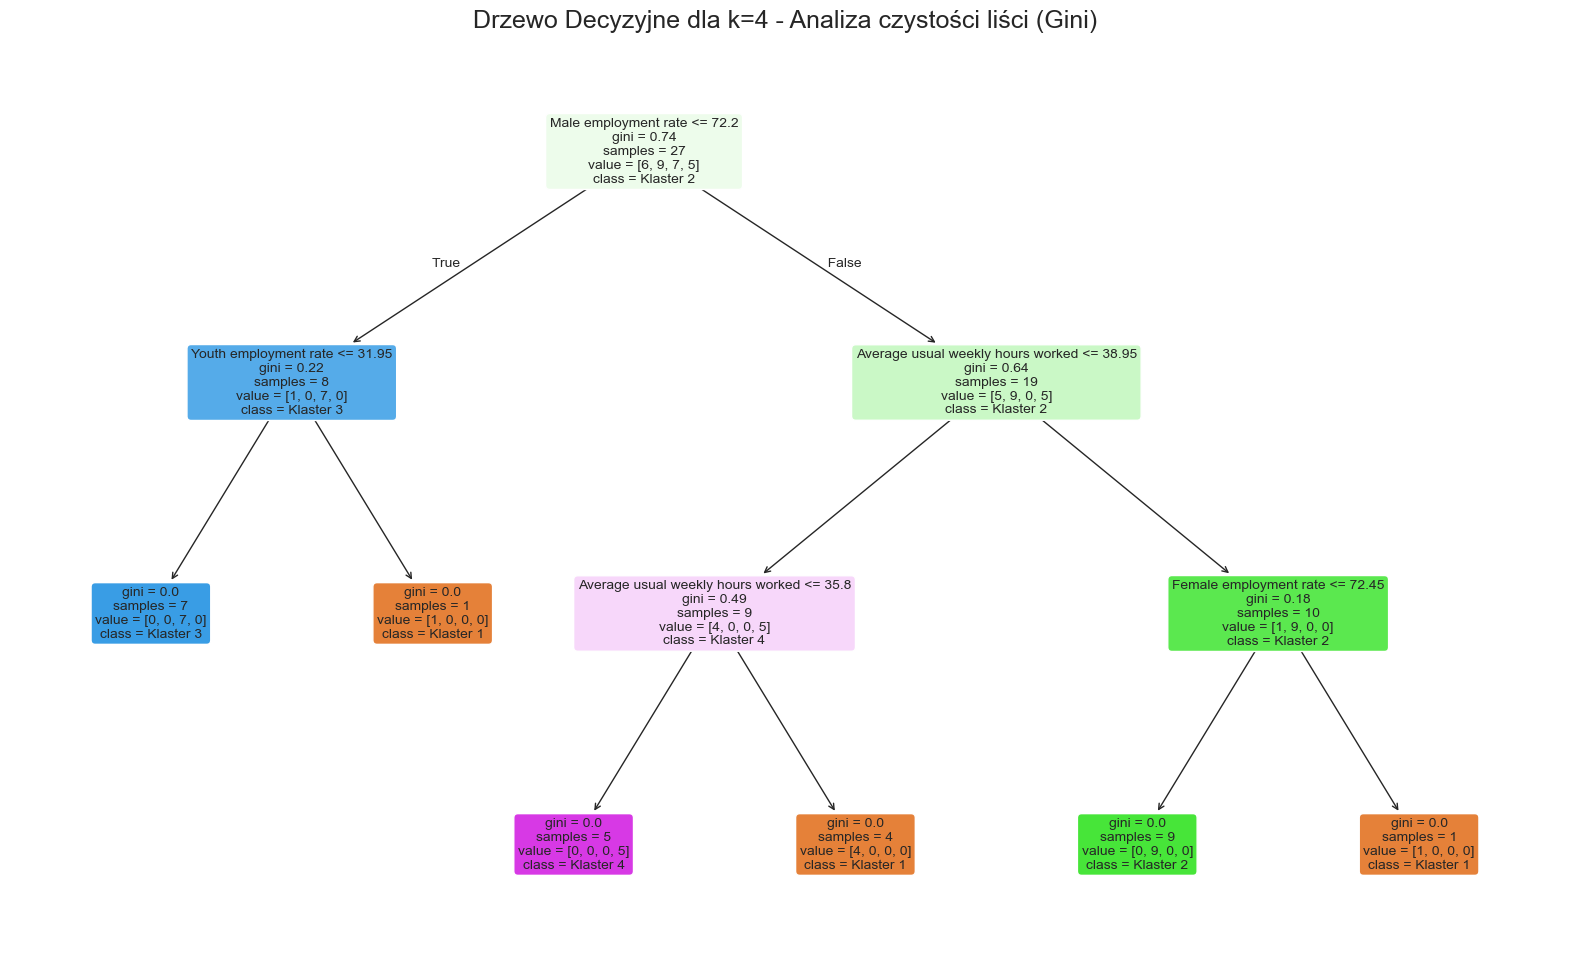

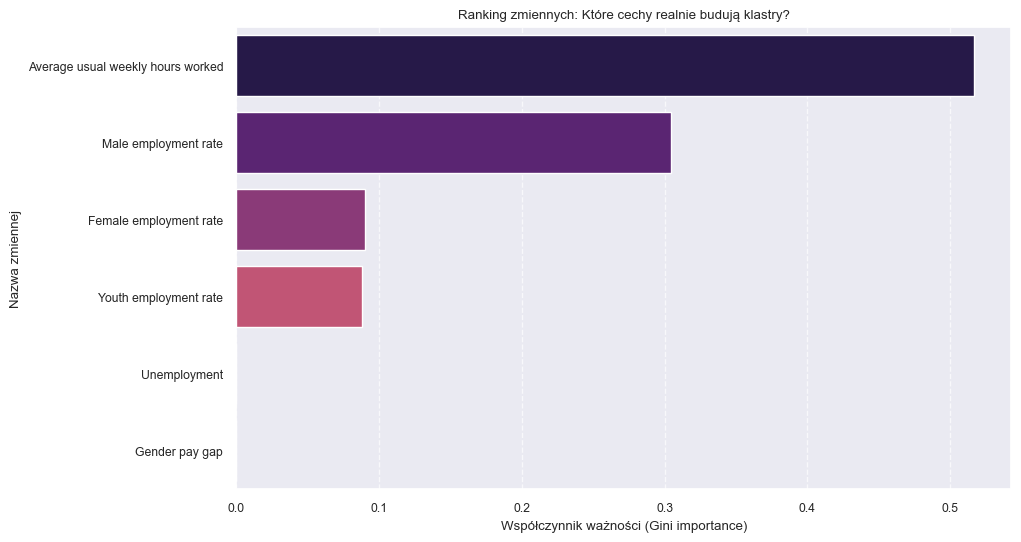


Szczegółowe wartości ważności zmiennych:
Average usual weekly hours worked    0.517179
Male employment rate                 0.304662
Female employment rate               0.090335
Youth employment rate                0.087825
Unemployment                         0.000000
Gender pay gap                       0.000000
dtype: float64


In [11]:
#drzewo decyzyjne

k = 4 

clustering = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
grupy = clustering.fit_predict(dane_skalowane_df)

df_results = dane.copy()
df_results['Cluster'] = grupy + 1 

from sklearn.tree import DecisionTreeClassifier, plot_tree

X = dane 
y = df_results['Cluster']

drzewo = DecisionTreeClassifier(
    criterion='gini', 
    max_depth=4,      
    min_samples_leaf=1, 
    random_state=42,
    min_samples_split = 2
)
drzewo.fit(X, y)

plt.figure(figsize=(20, 12)) # Zwiększony rozmiar dla lepszej czytelności klastrów
plot_tree(
    drzewo, 
    feature_names=X.columns.tolist(), 
    class_names=[f'Klaster {i}' for i in sorted(y.unique())], 
    filled=True, 
    rounded=True, 
    fontsize=10,
    precision=2 
)

plt.title(f"Drzewo Decyzyjne dla k={k} - Analiza czystości liści (Gini)", fontsize=18)
plt.show()

#wykres graficzny ważności zmiennych
waznosc_zmiennych = pd.Series(drzewo.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.grid(axis='x', linestyle='--', alpha=0.7)
sb.barplot(x=waznosc_zmiennych.values, y=waznosc_zmiennych.index, hue=waznosc_zmiennych.index, palette="magma")
plt.title("Ranking zmiennych: Które cechy realnie budują klastry?")
plt.xlabel("Współczynnik ważności (Gini importance)")
plt.ylabel("Nazwa zmiennej")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("\nSzczegółowe wartości ważności zmiennych:")
print(waznosc_zmiennych)